In [3]:
# 1) Imports and load data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.ensemble import ExtraTreesClassifier

print("ExtraTrees Model - UFC Fight Prediction")
print("="*50)

df = pd.read_csv("/Users/niko/Desktop/UFC-elo-ranking/build/fight_ml_dataset.csv")
print(df.shape)

ExtraTrees Model - UFC Fight Prediction
(8138, 73)


In [4]:
# 2) Feature selection and preprocessing (match other models)
# Exclude non-feature columns (metadata, identifiers, raw strings)
exclude_cols = [
    'DATE', 'EVENT', 'BOUT', 'fighter_a_name', 'fighter_b_name',
    'winner_label', 'WEIGHTCLASS', 'METHOD', 'decision_type',
    'method_class', 'decision_basis', 'TIME', 'TIME FORMAT',
    'REFEREE', 'DETAILS', 'URL', 'fighter_a_url', 'fighter_b_url',
    'fighter_name_A', 'fighter_name_B', 'weight_class_A', 'weight_class_B',
    'stance_A', 'stance_B', 'date_of_birth_A', 'date_of_birth_B',
    'debut_date_A', 'debut_date_B', 'last_fight_date_A', 'last_fight_date_B'
]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in ['target'] + exclude_cols]

X = df[feature_cols].copy()
y = df['target'].astype(int)

print(f"Features selected: {len(feature_cols)}")
print("Sample features:", feature_cols[:10])

# Handle missing values
if X.isna().sum().sum() > 0:
    X = X.fillna(X.median())

Features selected: 41
Sample features: ['method_multiplier', 'ROUND', 'rounds_scheduled', 'current_elo_rating_A', 'total_fights_A', 'total_wins_A', 'total_losses_A', 'total_draws_A', 'win_rate_A', 'age_A']


In [5]:
# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training target distribution: {y_train.value_counts().to_dict()}")

Training set size: (6510, 41)
Test set size: (1628, 41)
Training target distribution: {1: 4201, 0: 2309}


In [6]:
# 4) Train ExtraTrees (baseline) and evaluate
xtr = ExtraTreesClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)
xtr.fit(X_train, y_train)

proba = xtr.predict_proba(X_test)[:, 1]
preds = (proba >= 0.5).astype(int)

print("ExtraTrees Results (baseline):")
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(f"ROC AUC : {roc_auc_score(y_test, proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

ExtraTrees Results (baseline):
Accuracy: 0.8139
ROC AUC : 0.8781

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73       578
           1       0.85      0.87      0.86      1050

    accuracy                           0.81      1628
   macro avg       0.80      0.79      0.79      1628
weighted avg       0.81      0.81      0.81      1628



In [ ]:
# 5) Hyperparameter tuning (optimize accuracy; adjust as needed)
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [300, 500, 800],
    "max_depth": [None, 8, 12, 16],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7, 0.9, 1.0],
    "bootstrap": [False]  # ExtraTrees typically without bootstrap
}

base = ExtraTreesClassifier(random_state=42, n_jobs=-1)
rs = RandomizedSearchCV(
    base, param_distributions=param_dist, n_iter=25, cv=5,
    scoring="accuracy", n_jobs=-1, random_state=42
)
rs.fit(X_train, y_train)

best_xtr = rs.best_estimator_
proba_tuned = best_xtr.predict_proba(X_test)[:, 1]
preds_tuned = (proba_tuned >= 0.5).astype(int)

print("ExtraTrees Results (tuned):")
print(f"Accuracy: {accuracy_score(y_test, preds_tuned):.4f}")
print(f"ROC AUC : {roc_auc_score(y_test, proba_tuned):.4f}")
print("Best params:", rs.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, preds_tuned))

ExtraTrees Results (tuned):
Accuracy: 0.8213
ROC AUC : 0.8918
Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 16, 'bootstrap': False}

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       578
           1       0.85      0.87      0.86      1050

    accuracy                           0.82      1628
   macro avg       0.81      0.80      0.80      1628
weighted avg       0.82      0.82      0.82      1628



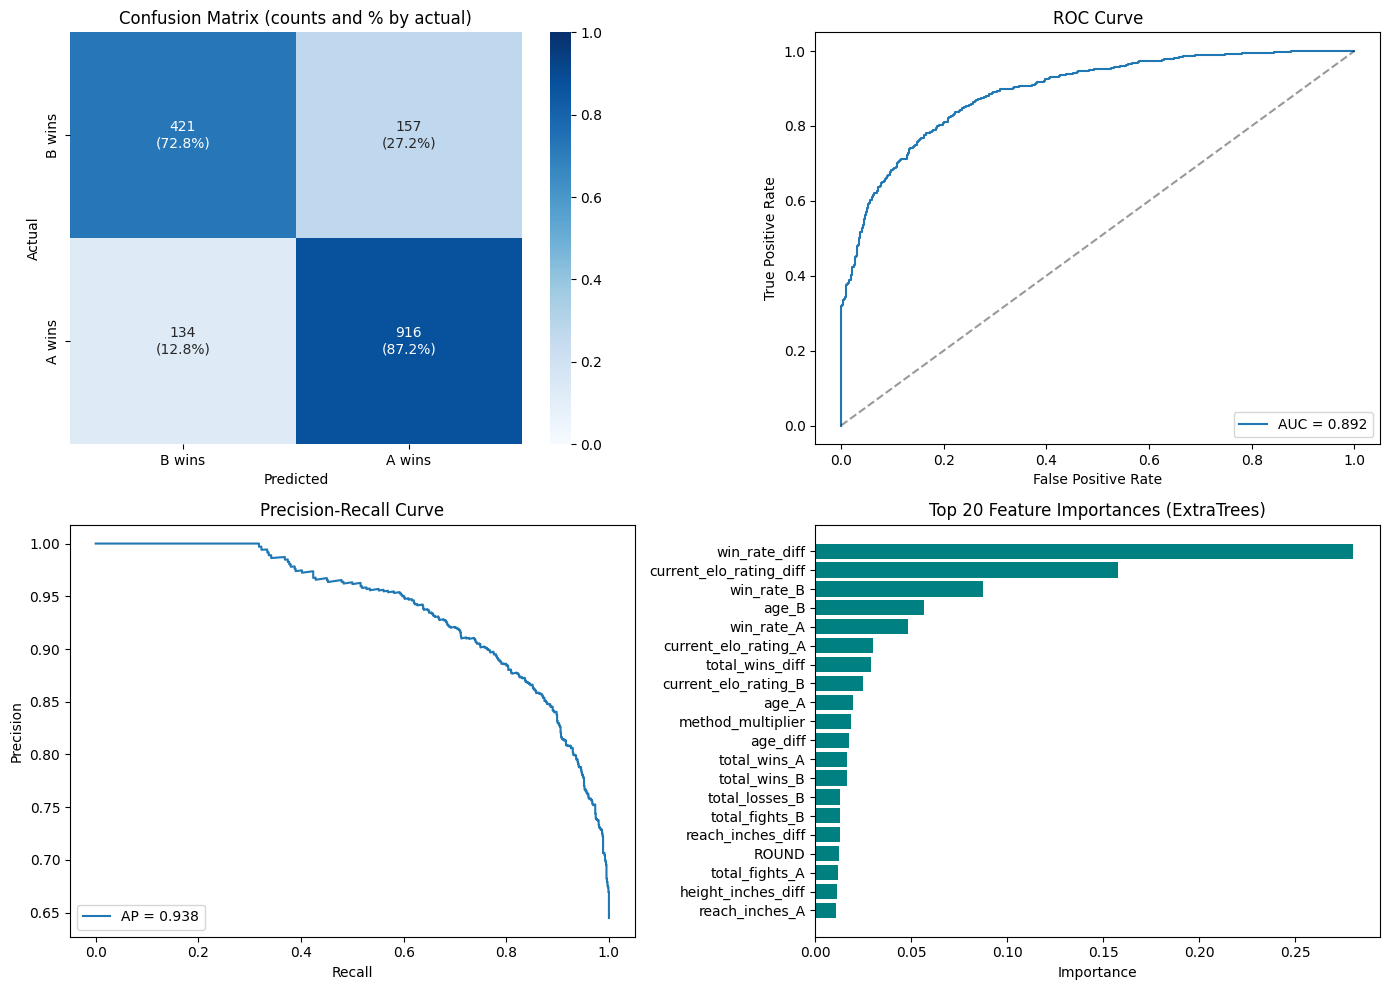

In [ ]:
# 6) Visualizations: Confusion Matrix (%), ROC, PR, Feature Importances (Top 20)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Use tuned if available, else baseline
clf = best_xtr if 'best_xtr' in locals() else xtr
y_proba = clf.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Confusion matrix with counts + row-wise %
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_perc = cm / cm.sum(axis=1, keepdims=True)
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_perc[i, j]:.1%})"
sns.heatmap(
    cm_perc, annot=annot, fmt='', cmap='Blues', vmin=0, vmax=1,
    xticklabels=['B wins', 'A wins'], yticklabels=['B wins', 'A wins'], ax=axes[0,0]
)
axes[0,0].set_title('Confusion Matrix (counts and % by actual)')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# 2) ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0,1].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.3f}')
axes[0,1].plot([0,1], [0,1], 'k--', alpha=0.4)
axes[0,1].set_title('ROC Curve')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].legend(loc='lower right')

# 3) Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1,0].plot(rec, prec, label=f'AP = {ap:.3f}')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].legend(loc='lower left')

# 4) Feature importances (Top 20)
fi = pd.DataFrame({'feature': feature_cols, 'importance': clf.feature_importances_}) \
       .sort_values('importance', ascending=False).head(20)
axes[1,1].barh(fi['feature'][::-1], fi['importance'][::-1], color='teal')
axes[1,1].set_title('Top 20 Feature Importances (ExtraTrees)')
axes[1,1].set_xlabel('Importance')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# 7) Save tuned model
import pickle, os

artifact = {"model": best_xtr, "features": feature_cols, "model_type": "ExtraTrees"}
with open("/Users/niko/Desktop/UFC-elo-ranking/models/extratrees_model.pkl", "wb") as f:
    pickle.dump(artifact, f)
print("✓ ExtraTrees (tuned) saved to /Users/niko/Desktop/UFC-elo-ranking/models/extratrees_model.pkl")

✓ ExtraTrees (tuned) saved to /Users/niko/Desktop/UFC-elo-ranking/models/extratrees_model.pkl
